# 📊 **Data Overview**

The dataset contains behavioral data for approximately **3,000 players** across a simulated **365-day** period.

The data was synthetically generated and designed to imitate realistic mobile gaming behavior, including sessions, purchases, retention patterns, and social interactions.

---
## Source Tables

| Table | Description |
|---|---|
| `players` | Player profiles, archetypes, platform, country, lifetime |
| `sessions` | Gameplay sessions and session metrics |
| `purchases` | In-game purchases and monetization events |
| `social_interactions` | Gifts, friend requests, and chat activity |
| `player_daily_activity` | Daily engagement and activity metrics |
| `session_events` | Event-level gameplay interactions |

---

## Dataset Summary

- ~3,000 players
- ~80,000 sessions
- ~11,000 purchases
- ~41,000 social interactions
- Multiple relational tables connected through `player_id`
---

## Environment Setup

In [1]:
# Imports
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

COLORS = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_PATH = "/content/drive/MyDrive/casino_analytics data"

DATA_PATH = f"{BASE_PATH}"

## Data Loading

The aggregated analytical tables:

```
- player_segments
- segment_summary
- cohort_retention
```


Were exported from BigQuery and loaded into pandas DataFrames for further analysis and visualization.

All SQL queries used for this project are stored separately and were used to prepare:
- player-level segmentation tables,
- cohort retention metrics,
- and aggregated KPI summaries.

In [4]:
segments = pd.read_csv(f"{DATA_PATH}/player_segments.csv")

segment_summary = pd.read_csv(f"{DATA_PATH}/segment_summary.csv")

cohorts = pd.read_csv(f"{DATA_PATH}/cohort_retention.csv")

## Initial Data Validation & Missing Values Handling

The following checks were performed:
- table structure review,
- column type validation,
- missing value inspection and handling.

In [5]:
segments.head()

,player_id,archetype,country_code,platform,device_tier,acquisition_channel,is_payer,is_churned,lifetime_days,install_date,last_active_date,total_sessions,avg_session_min,purchases,revenue_usd,social_interactions,recency_days,payer_segment
0,p_002757,whale_payer,CA,android,mid,facebook,1,0,168,2024-07-16,2024-12-31,126,24.9,89,998.11,54,0,high_value
1,p_002830,whale_payer,US,android,mid,facebook,1,0,216,2024-05-29,2024-12-31,134,24.1,80,945.20,53,0,high_value
2,p_002806,whale_payer,AU,android,low,google,1,0,179,2024-07-05,2024-12-31,126,25.4,84,941.16,48,0,high_value
3,p_002795,whale_payer,DE,android,low,tiktok,1,1,281,2024-01-10,2024-10-17,177,24.7,90,930.10,37,75,high_value
4,p_002720,whale_payer,MX,android,low,facebook,1,1,305,2024-01-28,2024-11-28,219,25.2,82,918.18,23,33,high_value


In [6]:
segments.shape

(3000, 18)

In [7]:
segments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            3000 non-null   object 
 1   archetype            3000 non-null   object 
 2   country_code         3000 non-null   object 
 3   platform             3000 non-null   object 
 4   device_tier          3000 non-null   object 
 5   acquisition_channel  3000 non-null   object 
 6   is_payer             3000 non-null   int64  
 7   is_churned           3000 non-null   int64  
 8   lifetime_days        3000 non-null   int64  
 9   install_date         3000 non-null   object 
 10  last_active_date     3000 non-null   object 
 11  total_sessions       3000 non-null   int64  
 12  avg_session_min      3000 non-null   float64
 13  purchases            3000 non-null   int64  
 14  revenue_usd          3000 non-null   float64
 15  social_interactions  3000 non-null   i

In [8]:
segments.isnull().sum()

,0
player_id,0
archetype,0
country_code,0
platform,0
device_tier,0
acquisition_channel,0
is_payer,0
is_churned,0
lifetime_days,0
install_date,0


In [9]:
segment_summary.head()

,archetype,total_players,avg_lifetime_days,avg_sessions,avg_session_min,arpu,arppu,avg_social_interactions,churn_rate_pct,payer_conversion_pct
0,whale_payer,150,237.8,171.3,25.0,604.44,604.44,37.1,46.7,100.0
1,minnow_payer,150,144.2,21.2,9.6,43.31,43.31,9.0,73.3,100.0
2,engaged,600,214.4,69.1,17.5,0.61,22.81,42.2,59.2,2.7
3,burst,300,13.6,9.5,12.5,0.39,10.69,10.4,94.0,3.7
4,casual,1500,47.1,4.4,6.0,0.02,3.55,3.6,86.5,0.5


In [10]:
segment_summary.shape

(6, 10)

In [11]:
segment_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   archetype                6 non-null      object 
 1   total_players            6 non-null      int64  
 2   avg_lifetime_days        6 non-null      float64
 3   avg_sessions             6 non-null      float64
 4   avg_session_min          6 non-null      float64
 5   arpu                     6 non-null      float64
 6   arppu                    5 non-null      float64
 7   avg_social_interactions  6 non-null      float64
 8   churn_rate_pct           6 non-null      float64
 9   payer_conversion_pct     6 non-null      float64
dtypes: float64(8), int64(1), object(1)
memory usage: 612.0+ bytes


In [12]:
segment_summary.isnull().sum()

,0
archetype,0
total_players,0
avg_lifetime_days,0
avg_sessions,0
avg_session_min,0
arpu,0
arppu,1
avg_social_interactions,0
churn_rate_pct,0
payer_conversion_pct,0


In [13]:
# Missing payer revenue metrics were replaced with `0`
# for visualization and modeling purposes.
segment_summary["arppu"] = (
    segment_summary["arppu"]
    .fillna(0)
)

In [14]:
segment_summary.isnull().sum()

,0
archetype,0
total_players,0
avg_lifetime_days,0
avg_sessions,0
avg_session_min,0
arpu,0
arppu,0
avg_social_interactions,0
churn_rate_pct,0
payer_conversion_pct,0


**Note 1:** Retention was calculated as the share of players active on D1, D7, D14, and D30 after installation. Due to the synthetic nature of the dataset, some cohorts may show non-monotonic retention values.

**Note 2:** November and December 2024 cohorts should be interpreted cautiously because the observation window does not fully cover 30 days after installation.

In [15]:
cohorts.head()

,cohort_month,cohort_size,d1_retention_pct,d7_retention_pct,d14_retention_pct,d30_retention_pct
0,2024-01,293,25.3,27.0,20.1,19.1
1,2024-02,302,31.1,29.1,31.5,24.8
2,2024-03,300,34.7,33.0,27.0,21.0
3,2024-04,304,31.3,29.9,23.4,22.0
4,2024-05,337,35.0,32.6,27.3,19.3


In [16]:
cohorts.shape

(12, 6)

In [17]:
cohorts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cohort_month       12 non-null     object 
 1   cohort_size        12 non-null     int64  
 2   d1_retention_pct   12 non-null     float64
 3   d7_retention_pct   12 non-null     float64
 4   d14_retention_pct  12 non-null     float64
 5   d30_retention_pct  12 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 708.0+ bytes


In [18]:
cohorts.isnull().sum()

,0
cohort_month,0
cohort_size,0
d1_retention_pct,0
d7_retention_pct,0
d14_retention_pct,0
d30_retention_pct,0


In [19]:
# Summary_statistics
summary_stats = pd.DataFrame({
    "Metric": [
        "Players",
        "Payers",
        "Churned Players",
        "Average Lifetime (days)",
        "Total Revenue"
    ],
    "Value": [
        len(segments),
        segments["is_payer"].sum(),
        segments["is_churned"].sum(),
        round(segments["lifetime_days"].mean(), 1),
        round(segments["revenue_usd"].sum(), 2)
    ]
})

summary_stats

,Metric,Value
0,Players,3000.00
1,Payers,334.00
2,Churned Players,2414.00
3,Average Lifetime (days),87.00
4,Total Revenue,97670.63


## Question 1. How is the player base distributed across behavioral segments?

First, I wanted to understand who makes up the player base and how players are distributed across behavioral segments.

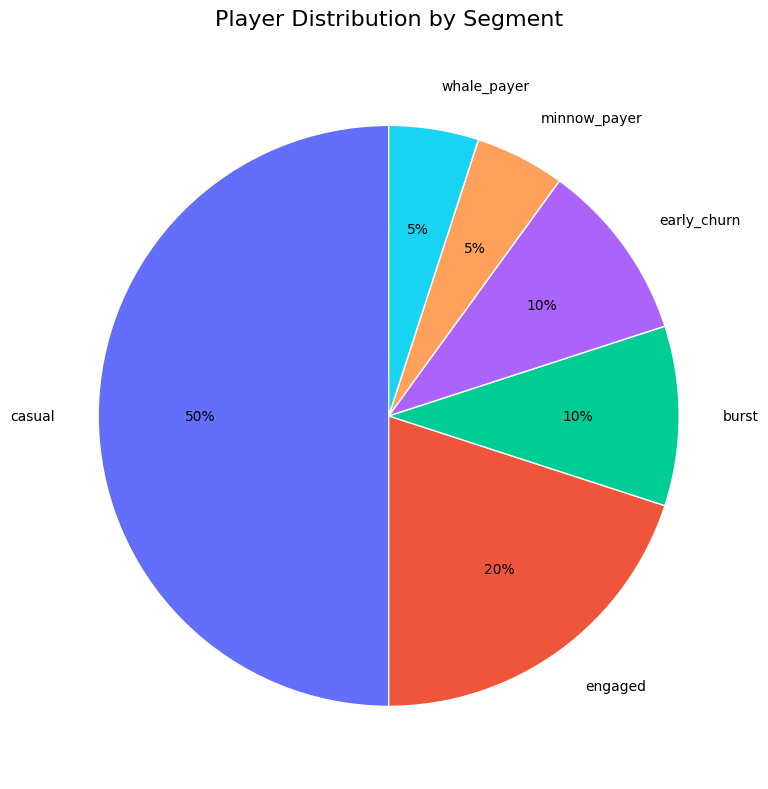

In [20]:
arch_counts = (
    segments["archetype"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(8, 8))

plt.pie(
    arch_counts,
    labels=arch_counts.index,
    colors=COLORS,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.65,      # відсотки всередині
    labeldistance=1.15,    # підписи зовні
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

plt.title(
    "Player Distribution by Segment",
    fontsize=16,
    pad=20
)

plt.tight_layout()
plt.show()

Key Finding
- Half of all players belong to the casual segment.
- Engaged players account for another 20% of the player base.
- Whale and minnow payers make up only a small share of players.
- Most users are not paying customers

Recommendation
- Focus on converting casual players into more engaged users.
- Keep high-value payer segments active through retention campaigns.
- Look for opportunities to increase monetization among engaged players.

## Question 2. How does player lifetime differ across segments?

Next, I looked at how long players stay in the game across different segments.

In [21]:
lifetime_stats = (
    segments.groupby("archetype")["lifetime_days"]
    .agg(["mean", "median"])
    .round(1)
    .sort_values(
        "median",
        ascending=False
    )
)

lifetime_stats

,mean,median
archetype,,
whale_payer,237.8,231.5
engaged,214.4,206.5
minnow_payer,144.2,137.0
casual,47.1,46.0
burst,13.6,13.0
early_churn,1.9,2.0


Insight
- Whale and engaged players stay active the longest.
- Minnow payers also show relatively strong retention.
- Burst players are active for a short period before dropping off.
- Early churn users leave almost immediately.

Recommendation
- Improve onboarding for early churn users.
- Re-engage burst players before they lose interest.
- Continue supporting engaged and whale players.

## Question 3. Which segments have the highest churn rate?

Since lifetime differs across segments, I also wanted to see which groups are most likely to churn.

In [22]:
churn_by_segment = segment_summary.sort_values("churn_rate_pct")

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=churn_by_segment["churn_rate_pct"],
        y=churn_by_segment["archetype"],
        mode="markers+text",
        text=churn_by_segment["churn_rate_pct"].round(1).astype(str) + "%",
        textposition="middle right",
        marker=dict(
            size=18,
            color=COLORS[:len(churn_by_segment)]
        )
    )
)

for y, x in zip(
    churn_by_segment["archetype"],
    churn_by_segment["churn_rate_pct"]
):
    fig.add_shape(
        type="line",
        x0=0,
        x1=x,
        y0=y,
        y1=y
    )

fig.update_layout(
    title="Churn Rate by Segment",
    xaxis_title="Churn Rate (%)",
    yaxis_title="Player Segment",
    showlegend=False,
    height=500
)

fig.show()

Insight
- Early churn users have the highest churn rate.
- Burst players also churn at very high levels.
- Engaged and whale players are much more likely to stay.
- Churn risk varies significantly across segments.

Recommendation
- Prioritize onboarding improvements for new players.
- Build retention mechanics for burst and casual users.
- Continue monitoring high-value segments.

## Question 4. How does retention change across acquisition cohorts?

To understand retention over time, I compared player cohorts acquired in different months.

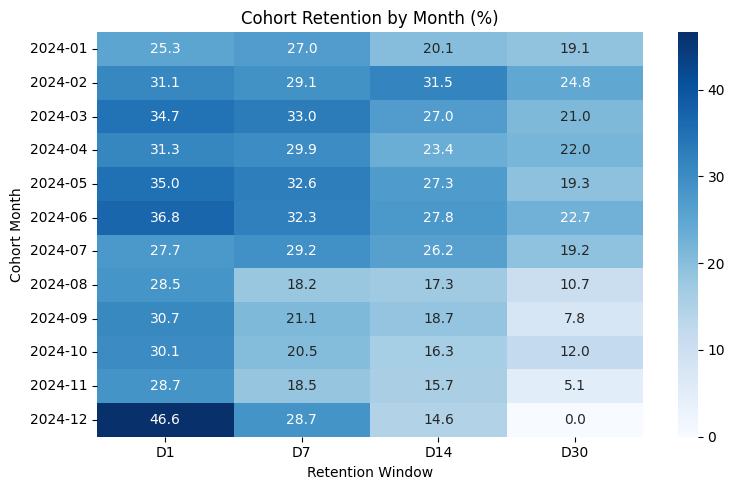

In [23]:
cohort_heat = cohorts.set_index("cohort_month")[
    ["d1_retention_pct", "d7_retention_pct",
     "d14_retention_pct", "d30_retention_pct"]
]

cohort_heat.columns = ["D1", "D7", "D14", "D30"]

plt.figure(figsize=(8, 5))

sns.heatmap(
    cohort_heat,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cohort Retention by Month (%)")
plt.xlabel("Retention Window")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

What stands out
- Retention steadily declines between D1 and D30.
- Earlier cohorts generally perform better.
- Recent cohorts show weaker long-term retention.

Recommendation
- Investigate what changed in recent acquisition periods.
- Focus on improving first-week retention.
- Track cohort performance regularly.

**Note:** November and December cohorts should be interpreted carefully because the full 30-day observation period is not available yet.

## Question 5. Which acquisition channels generate players with the longest lifetime?

Not all acquisition channels bring players with the same level of engagement, so I compared average lifetime across channels.

In [24]:
channel_lifetime = (
    segments
    .groupby("acquisition_channel")["lifetime_days"]
    .mean()
    .round(1)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    channel_lifetime,
    x="lifetime_days",
    y="acquisition_channel",
    orientation="h",
    color="acquisition_channel",
    text="lifetime_days",
    color_discrete_sequence=COLORS,
    title="Average Lifetime by Acquisition Channel"
)

fig.update_traces(
    texttemplate="%{text:.1f}",
    textposition="outside"
)

fig.update_layout(showlegend=False)

fig.show()

What stands out
- Lifetime differs noticeably between acquisition channels.
- TikTok, Google, and Facebook bring longer-living players.
- Unity Ads and AppLovin show lower average lifetime.

Recommendation
- Invest more in channels that attract long-term players.
- Review the quality of lower-performing channels.
- Consider lifetime alongside acquisition cost.

## Question 6. Is social activity associated with longer player lifetime?

I also wanted to check whether players who interact socially tend to stay in the game longer.

In [25]:
social_lifetime = segments.loc[
    segments["social_interactions"] > 0,
    "lifetime_days"
].median()

non_social_lifetime = segments.loc[
    segments["social_interactions"] == 0,
    "lifetime_days"
].median()

print(f"Social players median lifetime: {social_lifetime:.0f} days")
print(f"Non-social players median lifetime: {non_social_lifetime:.0f} days")
print(
    f"Difference: {social_lifetime - non_social_lifetime:.0f} days"
)

Social players median lifetime: 60 days
Non-social players median lifetime: 18 days
Difference: 42 days


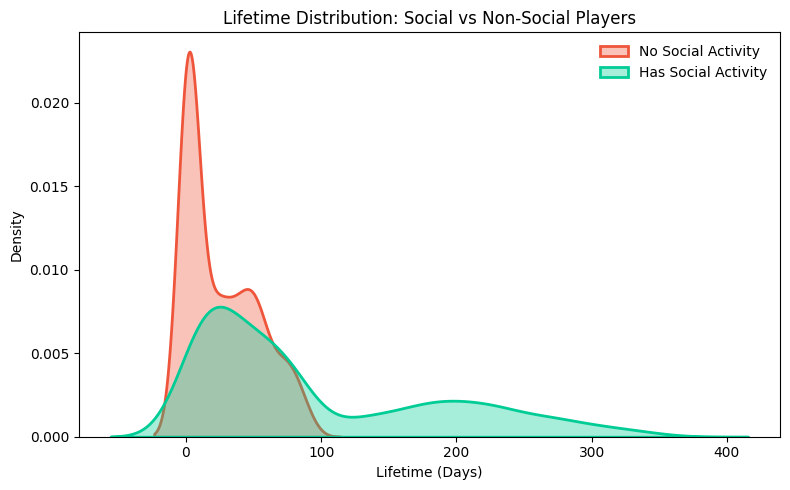

In [26]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    segments.loc[
        segments["social_interactions"] == 0,
        "lifetime_days"
    ],
    fill=True,
    color="#EF553B",
    alpha=0.35,
    linewidth=2,
    label="No Social Activity"
)

sns.kdeplot(
    segments.loc[
        segments["social_interactions"] > 0,
        "lifetime_days"
    ],
    fill=True,
    color="#00CC96",
    alpha=0.35,
    linewidth=2,
    label="Has Social Activity"
)

plt.title("Lifetime Distribution: Social vs Non-Social Players")
plt.xlabel("Lifetime (Days)")
plt.ylabel("Density")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

What stands out
- Socially active players have much longer lifetimes.
- Their lifetime distribution is shifted toward higher values.
- Social activity appears strongly linked to retention.

Recommendation
- Encourage players to interact with others early.
- Promote gifting and friend-based mechanics.
- Test additional social features to improve retention.

## Question 7. Can player churn be predicted using behavioral data?

Finally, I built machine learning models to see whether player churn can be predicted from player behavior.

- Logistic Regression
- Random Forest

I compared model performance using ROC-AUC and reviewed feature importance to understand which factors were most related to churn.

In [27]:
feature_cols = [
    "total_sessions",
    "avg_session_min",
    "revenue_usd",
    "purchases",
    "social_interactions",
    "platform_code",
    "device_tier_code",
    "channel_code"
]

In [28]:
print(feature_cols)

['total_sessions', 'avg_session_min', 'revenue_usd', 'purchases', 'social_interactions', 'platform_code', 'device_tier_code', 'channel_code']


In [29]:
le = LabelEncoder()

segments["platform_code"] = le.fit_transform(segments["platform"])
segments["device_tier_code"] = le.fit_transform(segments["device_tier"])
segments["channel_code"] = le.fit_transform(segments["acquisition_channel"])

ml_data = segments[feature_cols + ["is_churned"]].dropna()

X = ml_data[feature_cols]
y = ml_data["is_churned"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Players: {len(X):,}")
print(f"Churn Rate: {y.mean():.1%}")

Players: 3,000
Churn Rate: 80.5%


In [30]:
# Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_sc, y_train)

y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
y_pred_lr = lr.predict(X_test_sc)

auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"Logistic Regression AUC: {auc_lr:.3f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression AUC: 0.679
              precision    recall  f1-score   support

           0       0.35      0.54      0.42       117
           1       0.87      0.75      0.81       483

    accuracy                           0.71       600
   macro avg       0.61      0.65      0.61       600
weighted avg       0.77      0.71      0.73       600



In [31]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest AUC: {auc_rf:.3f}")
print(classification_report(y_test, y_pred_rf))

Random Forest AUC: 0.744
              precision    recall  f1-score   support

           0       0.45      0.27      0.34       117
           1       0.84      0.92      0.88       483

    accuracy                           0.79       600
   macro avg       0.65      0.60      0.61       600
weighted avg       0.76      0.79      0.77       600



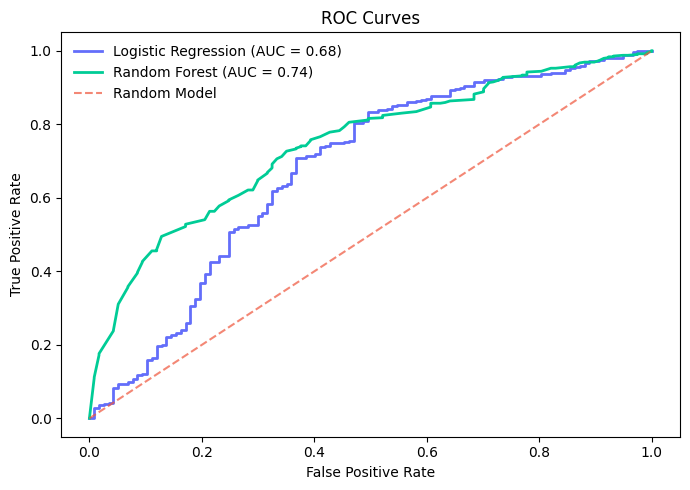

In [32]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_lr,
    tpr_lr,
    color="#636EFA",
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_lr:.2f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    color="#00CC96",
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="#EF553B",
    alpha=0.7,
    label="Random Model"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

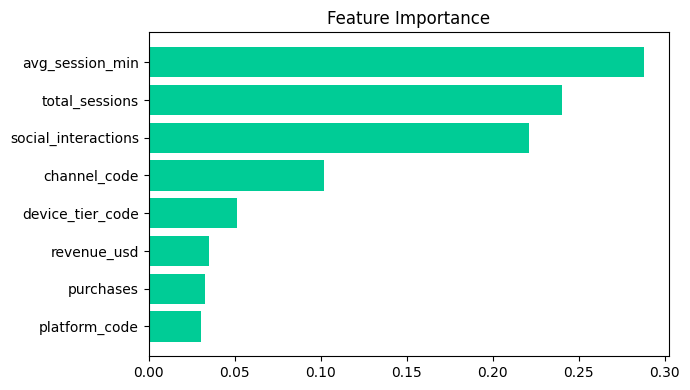

In [33]:
# Feature Importance

feat_imp = (
    pd.Series(
        rf.feature_importances_,
        index=feature_cols
    )
    .sort_values()
)

plt.figure(figsize=(7, 4))

plt.barh(
    feat_imp.index,
    feat_imp.values,
    color="#00CC96"
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

Insight
- Random Forest performed better than Logistic Regression.
- Session activity and social interactions were among the most useful predictors.
- Churn can be predicted with reasonable accuracy.

Recommendation
- Use the model as an early warning system.
- Monitor players whose activity starts to decline.
- Trigger retention campaigns before churn happens.

## Conclusion 🎯

The analysis showed that player engagement and social activity are closely linked to retention.

Whale and engaged players stay longer and churn less, while early_churn and burst segments offer the biggest retention opportunities.
Cohort analysis confirmed that retention drops over time, especially after the first days.

The Random Forest model reached an AUC of 0.74 and highlighted engagement-related features as the main churn drivers.